**IMPORTS**

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import torchvision.models as models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm 
import time
import sys
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [4]:
import torch
import numpy as np
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
!pip install pvlib
import pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 83.8 MB/s eta 0:00:00:00:0100:01


**LOAD DATASET**

In [6]:
ds = load_dataset("solarbench/SKIPPD")
train_data = ds["train"].sort("time")
test_data  = ds["test"].sort("time")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/455M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/439M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/419M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/90.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/349372 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14003 [00:00<?, ? examples/s]

In [7]:
def load_split(dataset):
    N = len(dataset)

    imgs = np.empty((N, 64, 64, 3), dtype=np.float32)
    pv   = np.empty(N, dtype=np.float32)
    time = []

    for i, row in enumerate(dataset):
        imgs[i] = np.array(row["image"], dtype=np.float32) / 255.0
        pv[i]   = row["pv"]
        time.append(row["time"])

    time = pd.to_datetime(time)

    return imgs, pv, time

imgs_tr, pv_tr, time_tr = load_split(train_data)
imgs_te, pv_te, time_te = load_split(test_data)

In [8]:
time_all = np.concatenate([time_tr, time_te])
pv_all   = np.concatenate([pv_tr, pv_te])
id_tr = np.arange(len(time_tr))
id_te = np.arange(len(time_te))

source = np.array(["tr"] * len(time_tr) + ["te"] * len(time_te))
idx_all = np.concatenate([id_tr, id_te])
order = np.argsort(time_all)

time_all = time_all[order]
pv_all   = pv_all[order]
source   = source[order]
idx_all  = idx_all[order]

In [9]:
df = pd.DataFrame({
    "time": time_all,
    "pv": pv_all
})

df["minute_of_day"] = df["time"].dt.hour * 60 + df["time"].dt.minute
pv_clear_map = df.groupby("minute_of_day")["pv"].quantile(0.99)
pv_clear = df["minute_of_day"].map(pv_clear_map).values
k_all = pv_all / (pv_clear)

In [11]:
def get_image(i):
    if source[i] == "tr":
        return imgs_tr[idx_all[i]]   # already in [0,1]
    else:
        return imgs_te[idx_all[i]]

In [12]:
lat = 37.427
lon = -122.174

times = pd.DatetimeIndex(time_all)
times = times.tz_convert("US/Pacific")

# Compute solar position
solpos = pvlib.solarposition.get_solarposition(
    time=times,
    latitude=lat,
    longitude=lon
)

zenith_all  = solpos["zenith"].values
azimuth_all = solpos["azimuth"].values

**SOLAR FEATURES**

In [13]:
SEQ = 12
K = 60

def make_indices(start, end):
    idx = []

    for i in range(start, end - SEQ - K):

        t = time_all[i : i + SEQ + K]
        dt = np.diff(t).astype("timedelta64[s]").astype(int)

        # ensure 1-minute continuity
        if np.all(dt == 60):
            idx.append(i)

    return np.array(idx)

In [14]:
N = len(pv_all)

train_end = int(0.84 * N)
val_end   = int(0.93 * N)

train_range = (0, train_end)
val_range   = (train_end, val_end)
test_range  = (val_end, N)

idx_tr  = make_indices(*train_range)
idx_val = make_indices(*val_range)
idx_te  = make_indices(*test_range)

**DATASET**

In [15]:
class SolarDataset(Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        # -------------------------
        # Image sequence
        # -------------------------
        imgs = [get_image(j) for j in range(idx, idx + SEQ)]

        x_np = np.stack(imgs)                   # (SEQ, H, W, C)
        x_np = np.transpose(x_np, (0, 3, 1, 2)) # (SEQ, C, H, W)

        x = torch.from_numpy(x_np).float()      # ✅ only once
        

        # -------------------------
        # Time indices
        # -------------------------
        t_now    = idx + SEQ - 1
        t_future = idx + SEQ + K - 1

        k_future = k_all[t_future]
        y = k_future

        # -------------------------
        # Aux
        # -------------------------
        zen_f = zenith_all[t_future]
        azi_f = azimuth_all[t_future]

        aux = np.array([
            np.cos(np.radians(zen_f)),
            np.sin(np.radians(azi_f))
        ], dtype=np.float32)

        return (
            x,  # ✅ already tensor — no re-wrapping
            torch.from_numpy(aux),
            torch.tensor(y, dtype=torch.float32)
        )

In [16]:
train_ds = SolarDataset(idx_tr)
val_ds   = SolarDataset(idx_val)
test_ds  = SolarDataset(idx_te)

**AUX FEATURE CORRELATION**

  0%|          | 0/50000 [00:00<?, ?it/s]

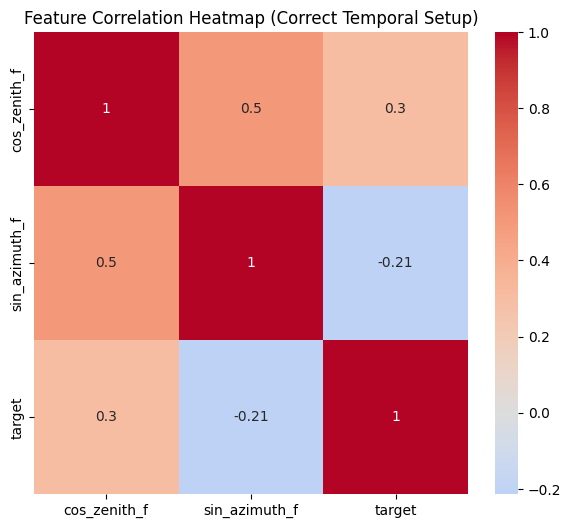

In [17]:
feature_names = ["cos_zenith_f","sin_azimuth_f", "target"]

data = []

# sample for efficiency
num_samples = min(50000, len(train_ds))
indices = np.random.choice(len(train_ds), num_samples, replace=False)

for i in tqdm(indices):

    x, aux, y = train_ds[i]

    # unpack aux properly
    cosz_f  = aux[0].item()
    sinA_f = aux[1].item()
    target = y.item()

    data.append([cosz_f,sinA_f, target])

# DataFrame
df = pd.DataFrame(data, columns=feature_names)

# correlation heatmap
plt.figure(figsize=(7,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Correct Temporal Setup)")
plt.show()

**MODEL**

In [24]:
import torch
import torch.nn as nn
from torchvision import models


class SequenceModel(nn.Module):

    def __init__(self, num_aux=2):
        super().__init__()

        # ------------------------
        # EFFICIENTNET-B0 (PYTORCH)
        # ------------------------
        backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")

        # remove classifier → keep features
        self.cnn = backbone.features

        # Freeze most layers
        for p in self.cnn.parameters():
            p.requires_grad = False

        # Unfreeze last stage
        for p in self.cnn[-1].parameters():
            p.requires_grad = True

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # ------------------------
        # TEMPORAL PROJECTION
        # ------------------------
        self.temporal_fc = nn.Sequential(
            nn.Linear(1280, 256),   # EfficientNet-B0 output
            nn.ReLU()
        )

        # ------------------------
        # FINAL HEAD
        # ------------------------
        self.head = nn.Sequential(
            nn.Linear(256 + num_aux, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x, aux):

        B, T, C, H, W = x.shape

        x = x.reshape(B*T, C, H, W)

        # CNN feature extraction
        feat = self.cnn(x)
        feat = self.pool(feat).flatten(1)   # (B*T, 1280)

        feat = feat.view(B, T, 1280)

        # temporal mean
        feat = feat.mean(dim=1)

        feat = self.temporal_fc(feat)

        out = torch.cat([feat, aux], dim=1)

        return self.head(out).squeeze(1)

In [25]:
g = torch.Generator()
g.manual_seed(seed)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,generator=g)
val_loader = DataLoader(val_ds,batch_size=64,shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64,shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SequenceModel().to(device)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr=1e-3)
loss_fn = nn.MSELoss()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]


In [26]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Frozen parameters    : {total - trainable:,}")


Total parameters     : 4,368,765
Trainable parameters : 773,377
Frozen parameters    : 3,595,388


**MODEL TRAINING**

In [27]:
from tqdm import tqdm
import torch

EPOCHS = 10

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ------------------------
    # TRAINING
    # ------------------------
    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)

    for x, aux, y in train_bar:

        x, aux, y = x.to(device), aux.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x, aux)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)

    # ------------------------
    # VALIDATION
    # ------------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)

        for x, aux, y in val_bar:

            x, aux, y = x.to(device), aux.to(device), y.to(device)

            pred = model(x, aux)
            loss = loss_fn(pred, y)

            val_loss += loss.item()
            val_bar.set_postfix(val_loss=loss.item())

    val_loss /= len(val_loader)

    # ------------------------
    # LOGGING
    # ------------------------
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f} | Val Loss = {val_loss:.4f}")
    # ------------------------
    # SAVE BEST MODEL
    # ------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Saved best model")


Epoch 1: Train Loss = 0.0149 | Val Loss = 0.0198
✅ Saved best model


Epoch 2: Train Loss = 0.0082 | Val Loss = 0.0176
✅ Saved best model


Epoch 3: Train Loss = 0.0067 | Val Loss = 0.0148
✅ Saved best model


Epoch 4: Train Loss = 0.0060 | Val Loss = 0.0173


Epoch 5: Train Loss = 0.0054 | Val Loss = 0.0164


Epoch 6: Train Loss = 0.0051 | Val Loss = 0.0166


Epoch 7: Train Loss = 0.0048 | Val Loss = 0.0169


Epoch 8: Train Loss = 0.0045 | Val Loss = 0.0131
✅ Saved best model


Epoch 9: Train Loss = 0.0043 | Val Loss = 0.0183


Epoch 10: Train Loss = 0.0042 | Val Loss = 0.0145


**METRICS**

In [32]:
model = SequenceModel().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, aux, y in test_loader:
        x, aux = x.to(device), aux.to(device)

        pred = model(x, aux)

        y_true.append(y.numpy())
        y_pred.append(pred.cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

In [33]:
pv_now = []
pv_future_true = []
pv_future_pred = []

for i in range(len(idx_te)):

    idx = idx_te[i]

    t_now = idx + SEQ - 1
    t_future = idx + SEQ + K - 1

    pv_t = pv_all[t_now]
    pv_f_true = pv_all[t_future]

    # ---- predicted k_future (direct) ----
    k_future_pred = y_pred[i]

    # optional clipping (recommended)
    k_future_pred = np.clip(k_future_pred, 0, 1.2)

    # ---- convert to PV ----
    pv_f_pred = k_future_pred * pv_clear[t_future]

    pv_now.append(pv_t)
    pv_future_true.append(pv_f_true)
    pv_future_pred.append(pv_f_pred)

pv_now = np.array(pv_now)
pv_true = np.array(pv_future_true)
pv_pred = np.array(pv_future_pred)

In [34]:
rmse = np.sqrt(mean_squared_error(pv_true, pv_pred))
mae  = mean_absolute_error(pv_true, pv_pred)
r2   = r2_score(pv_true, pv_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 3.646365732446592
MAE : 2.7223682622067917
R2  : 0.6773564108738992


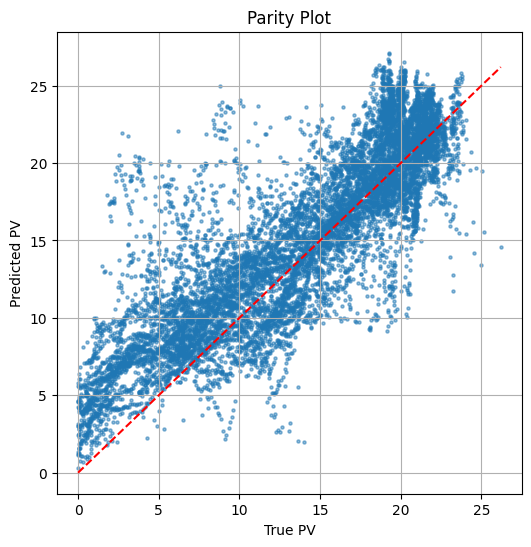

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(pv_true, pv_pred, s=5, alpha=0.5)
plt.plot([pv_true.min(), pv_true.max()],
         [pv_true.min(), pv_true.max()],
         'r--')

plt.xlabel("True PV")
plt.ylabel("Predicted PV")
plt.title("Parity Plot")
plt.grid()
plt.show()